In [5]:
# Importar la librería para manipulación de datos tabulares
import pandas as pd
# Importar la librería para operaciones numéricas y arreglos
import numpy as np
# Importar el modelo de regresión lineal para la ortogonalización
from sklearn.linear_model import LinearRegression
# Importar el escalador estándar para normalizar variables antes del clustering
from sklearn.preprocessing import StandardScaler
# Importar los algoritmos estadísticos de clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
# Importar las métricas matemáticas de evaluación de clústeres
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# ==============================================================================
# FASE 1: PREPROCESAMIENTO Y ORTOGONALIZACIÓN (ELIMINACIÓN DE SESGO DE AGUA)
# ==============================================================================

# 1. Cargar el dataset original en crudo desde el archivo CSV
df_crudo = pd.read_csv('../data/raw/intensidad_cobre_24.csv')

# 2. Definir explícitamente la lista de variables objetivo (canales de metales)
metales = ['n1fe', 'n2cu', 'n3zn', 'n4mo']

# 3. Calcular el umbral del percentil 90 para el canal de dispersión (agua)
umbral_agua_p90 = df_crudo['n6sc'].quantile(0.90)

# 4. Filtrar el dataframe reteniendo solo los estados estacionarios (sin flushing)
# Se usa .copy() para crear un dataframe independiente en memoria
df_filtrado = df_crudo[df_crudo['n6sc'] <= umbral_agua_p90].copy()

# 5. Iniciar un bucle para corregir cada metal iterativamente
for metal in metales:
    # Definir la variable independiente (X): El canal de dispersión (agua)
    X_agua = df_filtrado[['n6sc']]
    
    # Definir la variable dependiente (y): La intensidad cruda del metal actual
    y_metal_crudo = df_filtrado[metal]
    
    # Instanciar el modelo de regresión lineal simple
    modelo_regresion = LinearRegression()
    
    # Entrenar el modelo para encontrar la relación entre el agua y la caída del metal
    modelo_regresion.fit(X_agua, y_metal_crudo)
    
    # Predecir cuánta intensidad se pierde puramente por efecto de la dilución
    metal_esperado_por_dilucion = modelo_regresion.predict(X_agua)
    
    # Calcular el valor medio de la intensidad del metal para restaurar la escala física
    media_metal = y_metal_crudo.mean()
    
    # Calcular el residuo (valor real - valor espurio) y sumar la media
    metal_corregido_flotante = (y_metal_crudo - metal_esperado_por_dilucion) + media_metal
    
    # Redondear el valor al entero más cercano respetando la física de conteos de fotones
    metal_corregido_redondeado = metal_corregido_flotante.round(0)
    
    # Convertir el tipo de dato a entero explícitamente y guardarlo en una nueva columna
    df_filtrado[f'{metal}_corregido'] = metal_corregido_redondeado.astype(int)

# 6. Crear una lista explícita de las columnas base que queremos conservar
columnas_base = ['date', 'time', 'instance']

# 7. Crear una lista explícita con los nombres de las nuevas columnas corregidas
columnas_corregidas = [f'{metal}_corregido' for metal in metales]

# 8. Concatenar ambas listas para definir las columnas finales a mantener
columnas_finales = columnas_base + columnas_corregidas

# 9. Seleccionar solo las columnas de interés en el dataframe filtrado
df_limpio = df_filtrado[columnas_finales]

# 10. Ordenar cronológicamente el dataframe usando fecha y hora
df_limpio = df_limpio.sort_values(['date', 'time'])

# 11. Reiniciar el índice del dataframe para que sea continuo desde 0
df_limpio = df_limpio.reset_index(drop=True)

# ==============================================================================
# FASE 2: EVALUACIÓN DE CLUSTERING GEOMETALÚRGICO
# ==============================================================================

# 12. Extraer los valores numéricos puros (matriz X) para el clustering
matriz_X = df_limpio[columnas_corregidas].values

# 13. Instanciar el escalador estándar (Z-score normalization)
escalador = StandardScaler()

# 14. Ajustar el escalador y transformar la matriz X a media 0 y varianza 1
matriz_X_escalada = escalador.fit_transform(matriz_X)

# 15. Crear una lista vacía para almacenar los resultados de las métricas
resultados_metricas = []

# 16. Definir una función explícita para evaluar los clústeres
def evaluar_y_guardar_modelo(nombre_algoritmo, etiquetas_predichas, datos_escalados):
    # Encontrar las etiquetas únicas generadas por el modelo
    etiquetas_unicas = np.unique(etiquetas_predichas)
    
    # Crear una máscara booleana para excluir el ruido detectado (etiqueta -1 en DBSCAN)
    mascara_validos = etiquetas_predichas != -1
    
    # Filtrar las etiquetas reteniendo solo las asignaciones válidas
    etiquetas_validas = etiquetas_predichas[mascara_validos]
    
    # Contar la cantidad de clústeres válidos formados (debe ser mayor a 1 para evaluar)
    cantidad_clusteres = len(set(etiquetas_validas))
    
    # Condición lógica: solo evaluar si hay al menos 2 clústeres reales
    if cantidad_clusteres > 1:
        # Filtrar la matriz de datos excluyendo el ruido
        datos_validos = datos_escalados[mascara_validos]
        
        # Calcular el coeficiente de Silhouette (cohesión y separación)
        score_silueta = silhouette_score(datos_validos, etiquetas_validas)
        
        # Calcular el índice Davies-Bouldin (dispersión interna vs separación externa)
        score_db = davies_bouldin_score(datos_validos, etiquetas_validas)
        
        # Calcular el índice Calinski-Harabasz (ratio de varianza entre y dentro de clusters)
        score_ch = calinski_harabasz_score(datos_validos, etiquetas_validas)
        
        # Guardar las métricas calculadas como un diccionario en la lista de resultados
        resultados_metricas.append({
            'Algoritmo': nombre_algoritmo,
            'Clusters_Reales': cantidad_clusteres,
            'Silhouette_Score': round(score_silueta, 4),
            'Davies_Bouldin': round(score_db, 4),
            'Calinski_Harabasz': round(score_ch, 1)
        })

# 17. Evaluar el algoritmo K-Means iterando desde 2 hasta 6 clústeres
for k_clusters in range(2, 7):
    # Instanciar K-Means fijando la semilla aleatoria para reproducibilidad
    modelo_kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    # Entrenar el modelo y obtener las etiquetas asignadas a cada punto
    etiquetas_kmeans = modelo_kmeans.fit_predict(matriz_X_escalada)
    # Llamar a la función de evaluación pasando el nombre, etiquetas y datos
    evaluar_y_guardar_modelo(f'K-Means_k{k_clusters}', etiquetas_kmeans, matriz_X_escalada)

# 18. Evaluar el algoritmo Gaussian Mixture (GMM) iterando desde 2 hasta 6 clústeres
for gmm_clusters in range(2, 7):
    # Instanciar GMM fijando la semilla aleatoria
    modelo_gmm = GaussianMixture(n_components=gmm_clusters, random_state=42)
    # Entrenar GMM y obtener etiquetas
    etiquetas_gmm = modelo_gmm.fit_predict(matriz_X_escalada)
    # Llamar a la función de evaluación
    evaluar_y_guardar_modelo(f'GMM_k{gmm_clusters}', etiquetas_gmm, matriz_X_escalada)

# 19. Evaluar Clustering Aglomerativo Jerárquico iterando desde 2 hasta 6 clústeres
for aglom_clusters in range(2, 7):
    # Instanciar el modelo Aglomerativo (no requiere semilla aleatoria en su formulación base)
    modelo_aglomerativo = AgglomerativeClustering(n_clusters=aglom_clusters)
    # Entrenar y obtener etiquetas
    etiquetas_aglom = modelo_aglomerativo.fit_predict(matriz_X_escalada)
    # Llamar a la función de evaluación
    evaluar_y_guardar_modelo(f'Aglomerativo_k{aglom_clusters}', etiquetas_aglom, matriz_X_escalada)

# 20. Evaluar DBSCAN iterando sobre una grilla de hiperparámetros
# Definir lista de valores para epsilon (radio de vecindad)
lista_eps = [0.5, 0.8, 1.0, 1.2]
# Definir lista de valores para muestras mínimas (densidad requerida)
lista_min_samples = [4, 5, 10]

# Bucle anidado para explorar combinaciones de hiperparámetros de DBSCAN
for eps_actual in lista_eps:
    for min_samp_actual in lista_min_samples:
        # Instanciar DBSCAN con los parámetros actuales
        modelo_dbscan = DBSCAN(eps=eps_actual, min_samples=min_samp_actual)
        # Entrenar DBSCAN y obtener etiquetas (incluirá ruido como -1)
        etiquetas_dbscan = modelo_dbscan.fit_predict(matriz_X_escalada)
        # Construir el nombre del modelo con sus parámetros explícitos
        nombre_dbscan = f'DBSCAN_eps{eps_actual}_ms{min_samp_actual}'
        # Llamar a la función de evaluación
        evaluar_y_guardar_modelo(nombre_dbscan, etiquetas_dbscan, matriz_X_escalada)

# ==============================================================================
# FASE 3: SELECCIÓN DEL MEJOR MODELO Y EXPORTACIÓN FINAL
# ==============================================================================

# 21. Convertir la lista de resultados de métricas en un Dataframe de Pandas
df_resultados = pd.DataFrame(resultados_metricas)

# 22. Ordenar los resultados descendientemente según el score de Silhouette (el principal criterio)
df_resultados_ordenados = df_resultados.sort_values(by='Silhouette_Score', ascending=False)

# 23. Reiniciar el índice para acceder limpiamente a la primera fila (el mejor)
df_resultados_ordenados = df_resultados_ordenados.reset_index(drop=True)

# 24. Imprimir la tabla completa de evaluaciones para revisión técnica
print("=== TABLA DE EVALUACIÓN DE CLUSTERING ===")
print(df_resultados_ordenados.to_string())

# 25. Extraer dinámicamente el nombre y número de clusters del mejor modelo en la fila 0
mejor_algoritmo_nombre = df_resultados_ordenados.loc[0, 'Algoritmo']
mejor_cantidad_clusters = int(df_resultados_ordenados.loc[0, 'Clusters_Reales'])

# 26. Imprimir el ganador
print(f"\n[INFO] El mejor modelo según Silhouette es: {mejor_algoritmo_nombre}")

# 27. Lógica condicional para instanciar, re-entrenar el modelo ganador y asignar la etiqueta
if 'K-Means' in mejor_algoritmo_nombre:
    mejor_modelo = KMeans(n_clusters=mejor_cantidad_clusters, random_state=42, n_init=10)
    df_limpio['Cluster_Asignado'] = mejor_modelo.fit_predict(matriz_X_escalada)

elif 'GMM' in mejor_algoritmo_nombre:
    mejor_modelo = GaussianMixture(n_components=mejor_cantidad_clusters, random_state=42)
    df_limpio['Cluster_Asignado'] = mejor_modelo.fit_predict(matriz_X_escalada)

elif 'Aglomerativo' in mejor_algoritmo_nombre:
    mejor_modelo = AgglomerativeClustering(n_clusters=mejor_cantidad_clusters)
    df_limpio['Cluster_Asignado'] = mejor_modelo.fit_predict(matriz_X_escalada)

elif 'DBSCAN' in mejor_algoritmo_nombre:
    # Extraer los parámetros de la cadena (Ej. DBSCAN_eps0.5_ms10)
    # Dividiendo el string por guiones bajos
    partes_nombre = mejor_algoritmo_nombre.split('_')
    # Extraer epsilon quitando el prefijo 'eps' y convirtiendo a float
    mejor_eps = float(partes_nombre[1].replace('eps', ''))
    # Extraer min_samples quitando el prefijo 'ms' y convirtiendo a int
    mejor_ms = int(partes_nombre[2].replace('ms', ''))
    
    # Instanciar DBSCAN con los hiperparámetros ganadores
    mejor_modelo = DBSCAN(eps=mejor_eps, min_samples=mejor_ms)
    df_limpio['Cluster_Asignado'] = mejor_modelo.fit_predict(matriz_X_escalada)

# 28. Guardar el dataframe final (limpio, ortogonalizado y clasificado) en un CSV para el siguiente paso
df_limpio.to_csv('../data/processed/intensidades_cobre_24v2.csv', index=False)

print("\n[INFO] Ejecución completada. Archivo 'pipeline_metalurgico_final.csv' generado exitosamente.")

=== TABLA DE EVALUACIÓN DE CLUSTERING ===
             Algoritmo  Clusters_Reales  Silhouette_Score  Davies_Bouldin  Calinski_Harabasz
0   DBSCAN_eps0.5_ms10                2            0.4702          0.6182               92.9
1               GMM_k2                2            0.4241          1.3362               57.1
2      Aglomerativo_k4                4            0.3497          0.9420              161.5
3           K-Means_k4                4            0.3479          0.9417              173.9
4           K-Means_k3                3            0.3448          1.0288              160.1
5      Aglomerativo_k3                3            0.3269          1.0535              143.7
6           K-Means_k2                2            0.3260          1.2334              180.0
7      Aglomerativo_k2                2            0.3112          1.4297              149.8
8           K-Means_k6                6            0.2537          1.0360              162.3
9           K-Means_k5      

=== Cantidad de elementos por Clúster ===
Ruido (Outliers): 298 elementos
Clúster 0: 136 elementos
Clúster 1: 17 elementos


/tmp/ipykernel_8669/685940864.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_final, x='Cluster_Asignado', palette=paleta_colores)


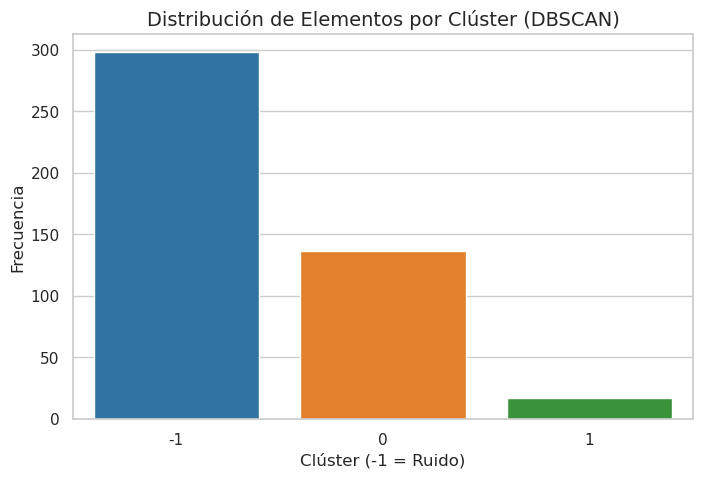


Generando matriz de dispersión (Pairplot)...


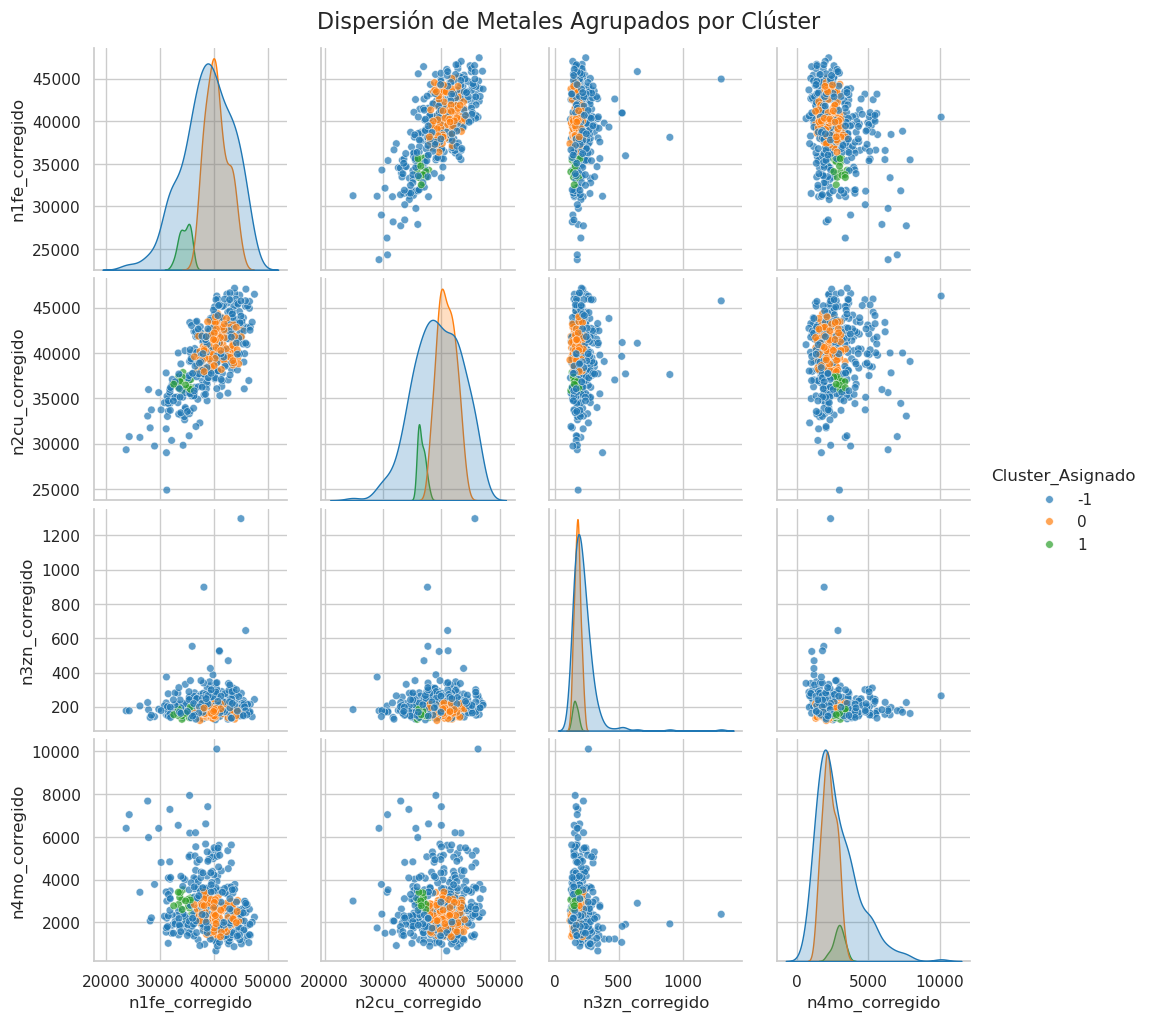

Generando visualización 2D con PCA...


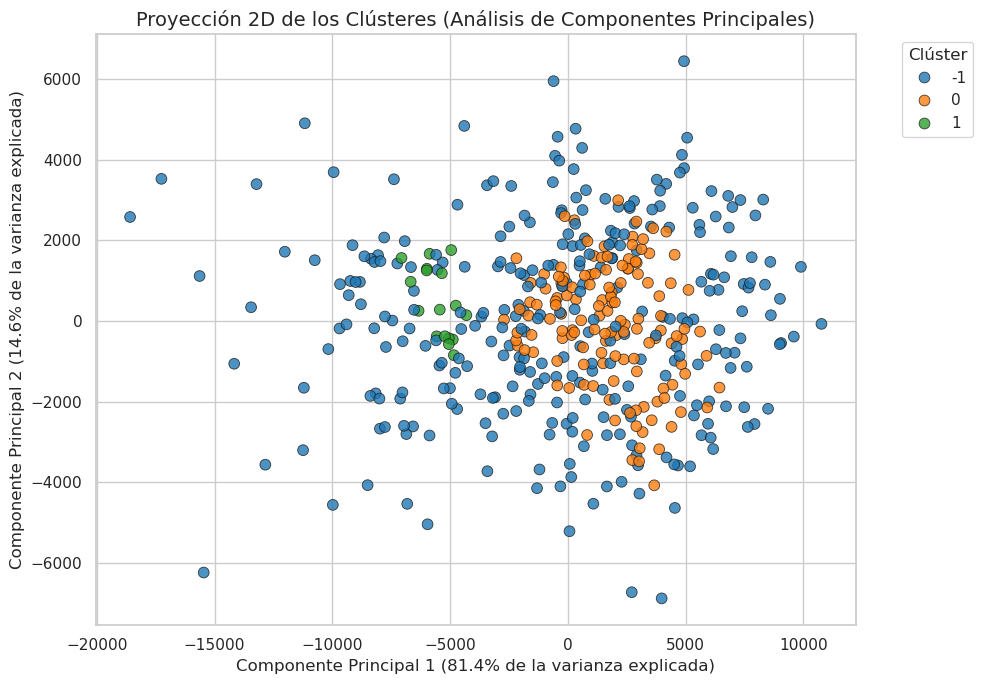

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# 1. Cargar el dataset final con los clústeres asignados
df_final = pd.read_csv('../data/processed/intensidades_cobre_24v2.csv')

# 2. Mostrar cuántos elementos pertenecen a cada grupo (clúster)
print("=== Cantidad de elementos por Clúster ===")
conteo_clusteres = df_final['Cluster_Asignado'].value_counts().sort_index()
for cluster, cantidad in conteo_clusteres.items():
    nombre = "Ruido (Outliers)" if cluster == -1 else f"Clúster {cluster}"
    print(f"{nombre}: {cantidad} elementos")

# Configurar el estilo visual
sns.set_theme(style="whitegrid")
paleta_colores = "tab10" # Paleta para distinguir bien los grupos

# 3. Gráfico 1: Gráfico de barras con la cantidad por clúster
plt.figure(figsize=(8, 5))
sns.countplot(data=df_final, x='Cluster_Asignado', palette=paleta_colores)
plt.title('Distribución de Elementos por Clúster (DBSCAN)', fontsize=14)
plt.xlabel('Clúster (-1 = Ruido)')
plt.ylabel('Frecuencia')
plt.show()

# Seleccionar las columnas de los metales para graficar la dispersión
columnas_metales = ['n1fe_corregido', 'n2cu_corregido', 'n3zn_corregido', 'n4mo_corregido']

# 4. Gráfico 2: Pairplot (Matriz de dispersión) para ver relaciones entre metales
print("\nGenerando matriz de dispersión (Pairplot)...")
g = sns.pairplot(df_final, vars=columnas_metales, hue='Cluster_Asignado', 
                 palette=paleta_colores, plot_kws={'alpha': 0.7, 's': 30})
g.fig.suptitle('Dispersión de Metales Agrupados por Clúster', y=1.02, fontsize=16)
plt.show()

# 5. Gráfico 3: Proyección en 2D usando PCA para visualizar cómo se separan los grupos
print("Generando visualización 2D con PCA...")
pca = PCA(n_components=2)
df_final[['PCA1', 'PCA2']] = pca.fit_transform(df_final[columnas_metales])

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_final, x='PCA1', y='PCA2', hue='Cluster_Asignado', 
                palette=paleta_colores, alpha=0.8, s=60, edgecolor='k')

# Añadir títulos y etiquetas con el porcentaje de varianza explicada
var_exp = pca.explained_variance_ratio_
plt.title('Proyección 2D de los Clústeres (Análisis de Componentes Principales)', fontsize=14)
plt.xlabel(f'Componente Principal 1 ({var_exp[0]:.1%} de la varianza explicada)')
plt.ylabel(f'Componente Principal 2 ({var_exp[1]:.1%} de la varianza explicada)')
plt.legend(title='Clúster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [7]:
# Importar librerías base para manipulación y matemáticas
import pandas as pd
import numpy as np

# Importar herramientas de Machine Learning y preprocesamiento
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Importar los algoritmos estadísticos de clustering (DBSCAN removido)
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering
from sklearn.mixture import GaussianMixture

# Importar las métricas de evaluación interna
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# ==============================================================================
# FASE 1: PREPROCESAMIENTO Y ORTOGONALIZACIÓN (ELIMINACIÓN DE SESGO DE AGUA)
# ==============================================================================

# 1. Cargar datos crudos
df_crudo = pd.read_csv('../data/raw/intensidad_cobre_24.csv')
metales = ['n1fe', 'n2cu', 'n3zn', 'n4mo']

# 2. Filtrado de flushing (eliminando inyecciones extremas de agua)
umbral_agua_p90 = df_crudo['n6sc'].quantile(0.90)
df_filtrado = df_crudo[df_crudo['n6sc'] <= umbral_agua_p90].copy()

# 3. Ortogonalización (Cálculo del residuo aislado del efecto dilución)
for metal in metales:
    X_agua = df_filtrado[['n6sc']]
    y_metal_crudo = df_filtrado[metal]
    
    modelo_regresion = LinearRegression()
    modelo_regresion.fit(X_agua, y_metal_crudo)
    
    metal_esperado_por_dilucion = modelo_regresion.predict(X_agua)
    media_metal = y_metal_crudo.mean()
    
    # El residuo restaura la señal real. Se redondea para mantener la física discreta (conteos)
    metal_corregido = (y_metal_crudo - metal_esperado_por_dilucion) + media_metal
    df_filtrado[f'{metal}_corregido'] = metal_corregido.round(0).astype(int)

# 4. Consolidación del dataframe limpio
columnas_base = ['date', 'time', 'instance']
columnas_corregidas = [f'{metal}_corregido' for metal in metales]
df_limpio = df_filtrado[columnas_base + columnas_corregidas].sort_values(['date', 'time']).reset_index(drop=True)

# ==============================================================================
# FASE 2: EVALUACIÓN DE CLUSTERING GEOMETALÚRGICO (100% ASIGNACIÓN)
# ==============================================================================

# 5. Escalamiento (Z-score) crítico para algoritmos basados en distancias
matriz_X = df_limpio[columnas_corregidas].values
escalador = StandardScaler()
matriz_X_escalada = escalador.fit_transform(matriz_X)

# 6. Inicializar contenedor de métricas
resultados_metricas = []

def evaluar_y_guardar_modelo(nombre_algoritmo, etiquetas_predichas, datos_escalados):
    # En estos algoritmos, no hay ruido descartado (-1), el 100% de datos se asigna
    cantidad_clusteres = len(np.unique(etiquetas_predichas))
    
    if cantidad_clusteres > 1:
        score_silueta = silhouette_score(datos_escalados, etiquetas_predichas)
        score_db = davies_bouldin_score(datos_escalados, etiquetas_predichas)
        score_ch = calinski_harabasz_score(datos_escalados, etiquetas_predichas)
        
        resultados_metricas.append({
            'Algoritmo': nombre_algoritmo,
            'Clusters': cantidad_clusteres,
            'Silhouette_Score': round(score_silueta, 4),
            'Davies_Bouldin': round(score_db, 4),
            'Calinski_Harabasz': round(score_ch, 1)
        })

# 7. Evaluar K-Means (Base Line Globular)
for k_clusters in range(2, 7):
    modelo_kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    etiquetas = modelo_kmeans.fit_predict(matriz_X_escalada)
    evaluar_y_guardar_modelo(f'K-Means_k{k_clusters}', etiquetas, matriz_X_escalada)

# 8. Evaluar Spectral Clustering (Grafos / Topologías Complejas)
for k_clusters in range(2, 7):
    # nearest_neighbors ayuda a mapear la conectividad local de la transición de la pulpa
    modelo_spectral = SpectralClustering(n_clusters=k_clusters, affinity='nearest_neighbors', random_state=42)
    etiquetas = modelo_spectral.fit_predict(matriz_X_escalada)
    evaluar_y_guardar_modelo(f'Spectral_k{k_clusters}', etiquetas, matriz_X_escalada)

# 9. Evaluar Gaussian Mixture Models (Distribución Probabilística de Matrices de Covarianza)
tipos_covarianza = ['full', 'tied', 'diag', 'spherical']
for cov_tipo in tipos_covarianza:
    for gmm_clusters in range(2, 7):
        modelo_gmm = GaussianMixture(n_components=gmm_clusters, covariance_type=cov_tipo, random_state=42)
        etiquetas = modelo_gmm.fit_predict(matriz_X_escalada)
        evaluar_y_guardar_modelo(f'GMM-{cov_tipo}_k{gmm_clusters}', etiquetas, matriz_X_escalada)

# 10. Evaluar Clustering Aglomerativo Jerárquico (Conectividad Ascendente)
for k_clusters in range(2, 7):
    modelo_aglomerativo = AgglomerativeClustering(n_clusters=k_clusters)
    etiquetas = modelo_aglomerativo.fit_predict(matriz_X_escalada)
    evaluar_y_guardar_modelo(f'Aglomerativo_k{k_clusters}', etiquetas, matriz_X_escalada)

# ==============================================================================
# FASE 3: SELECCIÓN ALGORÍTMICA DEL MEJOR MODELO (AUTOMATIZADA)
# ==============================================================================

# 11. Estructurar resultados y ordenar por cohesión matemática (Silhouette)
df_resultados = pd.DataFrame(resultados_metricas)
df_resultados_ordenados = df_resultados.sort_values(by='Silhouette_Score', ascending=False).reset_index(drop=True)

print("=== TOP 15 MODELOS DE AGRUPACIÓN EVALUADOS ===")
print(df_resultados_ordenados.head(15).to_string())

# 12. Extracción dinámica de los parámetros del modelo ganador
mejor_algoritmo_nombre = df_resultados_ordenados.loc[0, 'Algoritmo']
mejor_cantidad_clusters = int(df_resultados_ordenados.loc[0, 'Clusters'])

print(f"\n[INFO] Entrenando el modelo ganador final: {mejor_algoritmo_nombre}")

# 13. Reinstanciar estrictamente el modelo ganador en base a la sintaxis del nombre
if 'K-Means' in mejor_algoritmo_nombre:
    mejor_modelo = KMeans(n_clusters=mejor_cantidad_clusters, random_state=42, n_init=10)

elif 'Spectral' in mejor_algoritmo_nombre:
    mejor_modelo = SpectralClustering(n_clusters=mejor_cantidad_clusters, affinity='nearest_neighbors', random_state=42)

elif 'GMM' in mejor_algoritmo_nombre:
    # Parseo dinámico del tipo de covarianza (Ej: "GMM-full_k2" -> extrae "full")
    covarianza_ganadora = mejor_algoritmo_nombre.split('-')[1].split('_')[0]
    mejor_modelo = GaussianMixture(n_components=mejor_cantidad_clusters, covariance_type=covarianza_ganadora, random_state=42)

elif 'Aglomerativo' in mejor_algoritmo_nombre:
    mejor_modelo = AgglomerativeClustering(n_clusters=mejor_cantidad_clusters)

# 14. Ejecutar el etiquetado final sin dejar muestras huérfanas (0% Ruido garantizado)
df_limpio['Cluster_Asignado'] = mejor_modelo.fit_predict(matriz_X_escalada)

# 15. Exportar Pipeline final
df_limpio.to_csv('pipeline_metalurgico_final_sin_ruido.csv', index=False)
print("\n[INFO] Archivo 'pipeline_metalurgico_final_sin_ruido.csv' generado. El 100% de la producción ha sido etiquetada.")

=== TOP 15 MODELOS DE AGRUPACIÓN EVALUADOS ===
           Algoritmo  Clusters  Silhouette_Score  Davies_Bouldin  Calinski_Harabasz
0        GMM-tied_k2         2            0.6497          0.7393               68.7
1        GMM-full_k2         2            0.4241          1.3362               57.1
2        GMM-diag_k2         2            0.4135          1.1555               59.5
3        GMM-tied_k3         3            0.3639          0.9324              145.8
4        GMM-diag_k3         3            0.3598          1.1125              145.3
5    Aglomerativo_k4         4            0.3497          0.9420              161.5
6        GMM-tied_k4         4            0.3480          0.9236              141.5
7         K-Means_k4         4            0.3479          0.9417              173.9
8         K-Means_k3         3            0.3448          1.0288              160.1
9   GMM-spherical_k2         2            0.3437          1.5999              129.5
10   Aglomerativo_k3         

=== Cantidad de elementos por Clúster ===
Clúster 0: 6 elementos
Clúster 1: 445 elementos


/tmp/ipykernel_8669/2967199485.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_final, x='Cluster_Asignado', palette=paleta_colores)


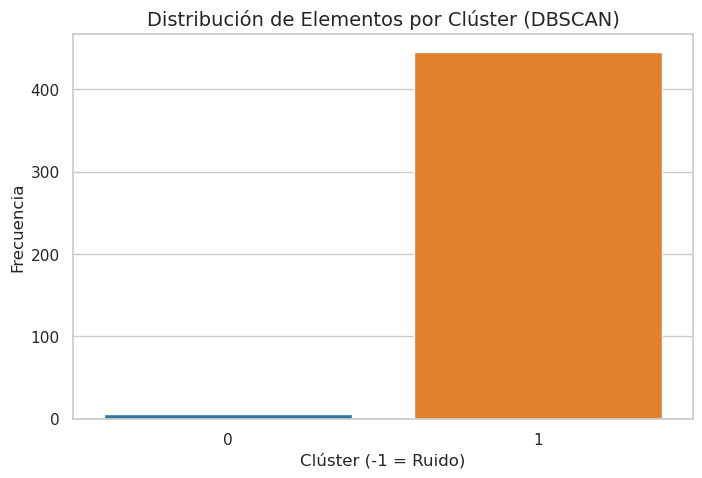


Generando matriz de dispersión (Pairplot)...


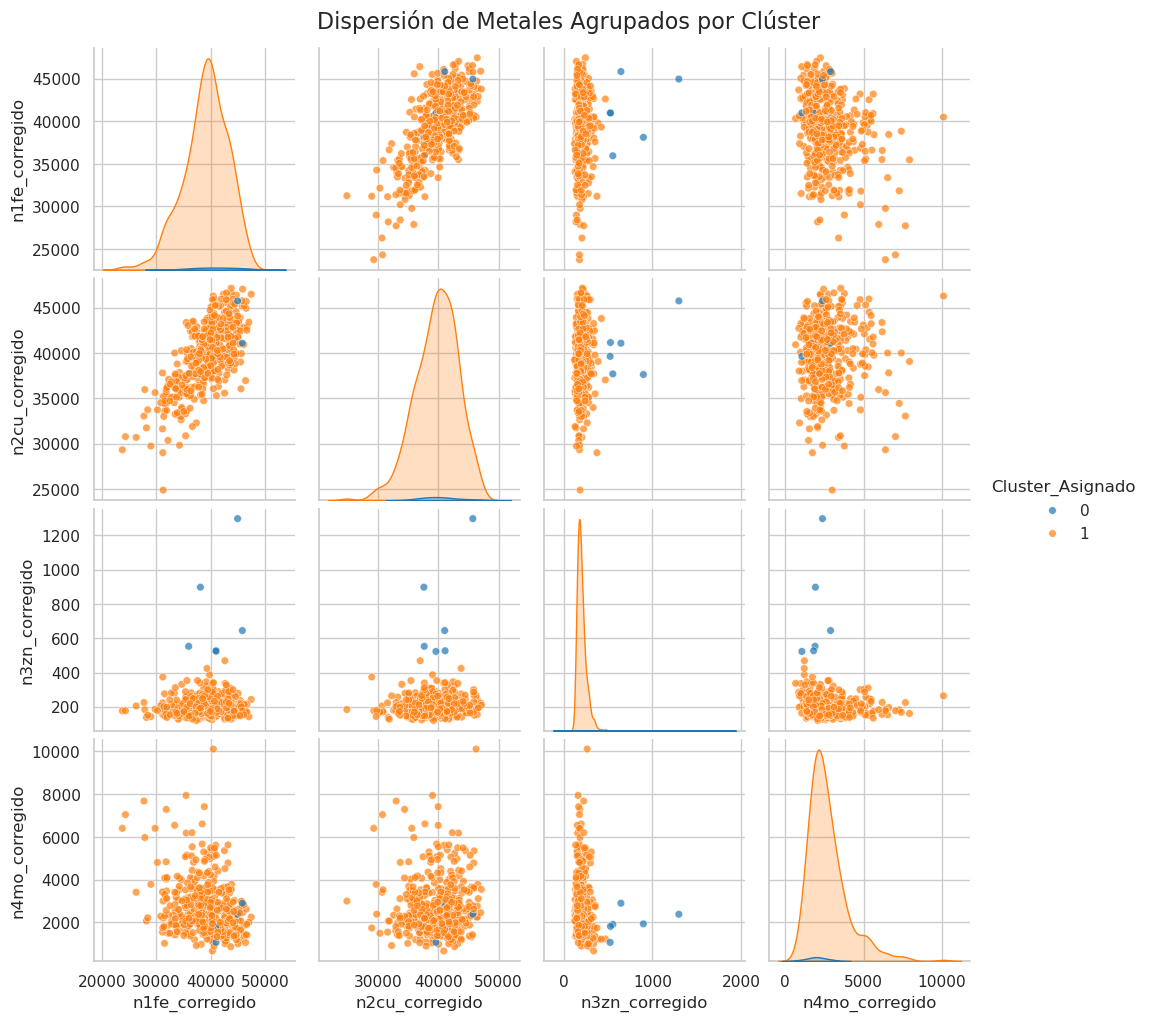

Generando visualización 2D con PCA...


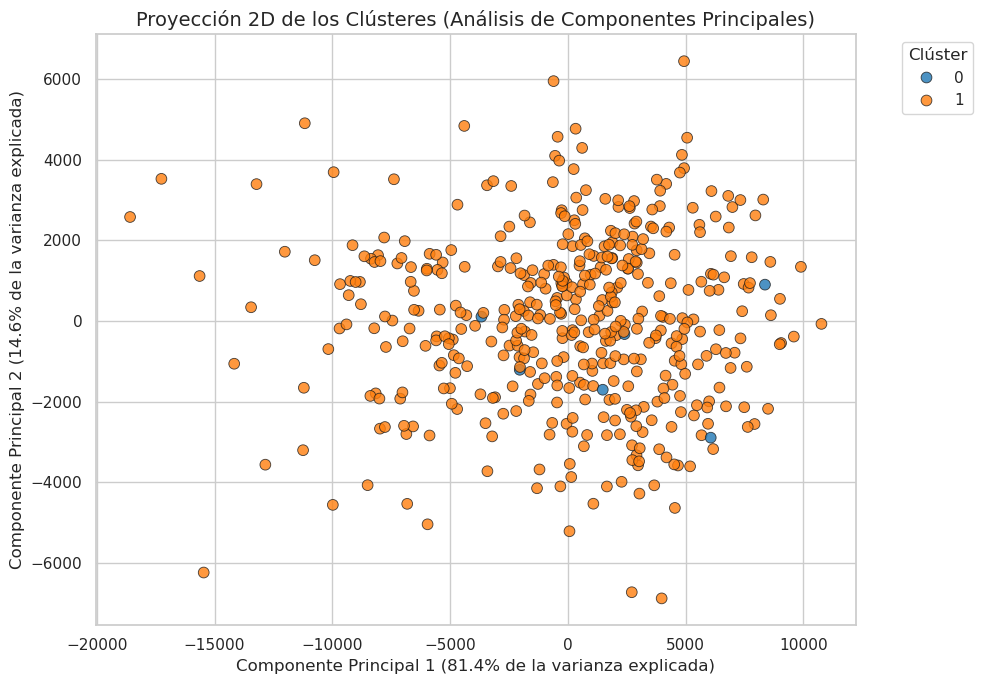

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# 1. Cargar el dataset final con los clústeres asignados
df_final = pd.read_csv('pipeline_metalurgico_final_sin_ruido.csv')

# 2. Mostrar cuántos elementos pertenecen a cada grupo (clúster)
print("=== Cantidad de elementos por Clúster ===")
conteo_clusteres = df_final['Cluster_Asignado'].value_counts().sort_index()
for cluster, cantidad in conteo_clusteres.items():
    nombre = "Ruido (Outliers)" if cluster == -1 else f"Clúster {cluster}"
    print(f"{nombre}: {cantidad} elementos")

# Configurar el estilo visual
sns.set_theme(style="whitegrid")
paleta_colores = "tab10" # Paleta para distinguir bien los grupos

# 3. Gráfico 1: Gráfico de barras con la cantidad por clúster
plt.figure(figsize=(8, 5))
sns.countplot(data=df_final, x='Cluster_Asignado', palette=paleta_colores)
plt.title('Distribución de Elementos por Clúster (DBSCAN)', fontsize=14)
plt.xlabel('Clúster (-1 = Ruido)')
plt.ylabel('Frecuencia')
plt.show()

# Seleccionar las columnas de los metales para graficar la dispersión
columnas_metales = ['n1fe_corregido', 'n2cu_corregido', 'n3zn_corregido', 'n4mo_corregido']

# 4. Gráfico 2: Pairplot (Matriz de dispersión) para ver relaciones entre metales
print("\nGenerando matriz de dispersión (Pairplot)...")
g = sns.pairplot(df_final, vars=columnas_metales, hue='Cluster_Asignado', 
                 palette=paleta_colores, plot_kws={'alpha': 0.7, 's': 30})
g.fig.suptitle('Dispersión de Metales Agrupados por Clúster', y=1.02, fontsize=16)
plt.show()

# 5. Gráfico 3: Proyección en 2D usando PCA para visualizar cómo se separan los grupos
print("Generando visualización 2D con PCA...")
pca = PCA(n_components=2)
df_final[['PCA1', 'PCA2']] = pca.fit_transform(df_final[columnas_metales])

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_final, x='PCA1', y='PCA2', hue='Cluster_Asignado', 
                palette=paleta_colores, alpha=0.8, s=60, edgecolor='k')

# Añadir títulos y etiquetas con el porcentaje de varianza explicada
var_exp = pca.explained_variance_ratio_
plt.title('Proyección 2D de los Clústeres (Análisis de Componentes Principales)', fontsize=14)
plt.xlabel(f'Componente Principal 1 ({var_exp[0]:.1%} de la varianza explicada)')
plt.ylabel(f'Componente Principal 2 ({var_exp[1]:.1%} de la varianza explicada)')
plt.legend(title='Clúster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# 1. Cargar los datos ortogonalizados (fase previa)
df_limpio = pd.read_csv('data/processed/intensidades_cobre_24v1.csv')
metales_corregidos = ['n1fe_corregido', 'n2cu_corregido', 'n3zn_corregido', 'n4mo_corregido']

# 2. Escalar datos para la primera pasada
matriz_X = df_limpio[metales_corregidos].values
escalador_1 = StandardScaler()
X_escalada_1 = escalador_1.fit_transform(matriz_X)

# 3. Primera pasada: Identificar las 6 anomalías con GMM-tied_k2
gmm_1 = GaussianMixture(n_components=2, covariance_type='tied', random_state=42)
df_limpio['Cluster_Inicial'] = gmm_1.fit_predict(X_escalada_1)

# Determinar cuál es el clúster minoritario (las anomalías)
conteo = df_limpio['Cluster_Inicial'].value_counts()
cluster_anomalo = conteo.idxmin()
cluster_normal = conteo.idxmax()

# 4. Aislar y mostrar las anomalías para auditoría
df_anomalias = df_limpio[df_limpio['Cluster_Inicial'] == cluster_anomalo]
print("=== REGISTRO DE LAS 6 ANOMALÍAS ELIMINADAS (PARA REVISAR EN PI SYSTEM) ===")
print(df_anomalias[['date', 'time'] + metales_corregidos].to_string(index=False))

# 5. Purgar las anomalías (quedarnos con los 445 sanos)
df_sano = df_limpio[df_limpio['Cluster_Inicial'] == cluster_normal].copy()
df_sano = df_sano.drop(columns=['Cluster_Inicial']).reset_index(drop=True)

print(f"\n[INFO] Datos originales: {len(df_limpio)} | Datos tras poda: {len(df_sano)}")

# ==============================================================================
# FASE 2: RE-CLUSTERING SOBRE DATOS SANOS
# ==============================================================================

# 6. Re-escalar (CRÍTICO: el centroide cambió al quitar los outliers)
matriz_X_sana = df_sano[metales_corregidos].values
escalador_2 = StandardScaler()
X_escalada_sana = escalador_2.fit_transform(matriz_X_sana)

# 7. Aplicar GMM-tied_k2 nuevamente
gmm_2 = GaussianMixture(n_components=3, covariance_type='tied', random_state=42)
df_sano['Cluster_Final'] = gmm_2.fit_predict(X_escalada_sana)

# 8. Evaluar el nuevo desempeño matemático
score_silueta = silhouette_score(X_escalada_sana, df_sano['Cluster_Final'])
score_db = davies_bouldin_score(X_escalada_sana, df_sano['Cluster_Final'])
score_ch = calinski_harabasz_score(X_escalada_sana, df_sano['Cluster_Final'])

print("\n=== NUEVAS MÉTRICAS DEL MODELO GMM-tied_k2 (SOBRE DATOS SANOS) ===")
print(f"Silhouette Score (↑): {score_silueta:.4f}")
print(f"Davies-Bouldin (↓): {score_db:.4f}")
print(f"Calinski-Harabasz (↑): {score_ch:.1f}")

# 9. Ver la nueva distribución
print("\n=== NUEVA DISTRIBUCIÓN DE CLÚSTERES ===")
print(df_sano['Cluster_Final'].value_counts().sort_index().to_string())

# 10. Guardar pipeline purgado
df_sano.to_csv('intensidades_sanas_clusterizadas.csv', index=False)

=== REGISTRO DE LAS 6 ANOMALÍAS ELIMINADAS (PARA REVISAR EN PI SYSTEM) ===
      date     time  n1fe_corregido  n2cu_corregido  n3zn_corregido  n4mo_corregido
2023-02-24 11:27:07           35952           37690             553            1907
2023-06-21 11:12:45           40992           39623             523            1066
2024-04-14 06:57:26           44963           45737            1298            2380
2024-05-01 10:35:54           45840           41072             645            2897
2024-06-07 10:58:05           40977           41148             527            1815
2024-09-27 12:32:27           38117           37622             898            1931

[INFO] Datos originales: 451 | Datos tras poda: 445

=== NUEVAS MÉTRICAS DEL MODELO GMM-tied_k2 (SOBRE DATOS SANOS) ===
Silhouette Score (↑): 0.3071
Davies-Bouldin (↓): 1.1430
Calinski-Harabasz (↑): 139.8

=== NUEVA DISTRIBUCIÓN DE CLÚSTERES ===
Cluster_Final
0     50
1    320
2     75


=== Cantidad de elementos por Clúster ===
Clúster 0: 50 elementos
Clúster 1: 320 elementos
Clúster 2: 75 elementos


/tmp/ipykernel_32015/892234665.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_final, x='Cluster_Final', palette=paleta_colores)


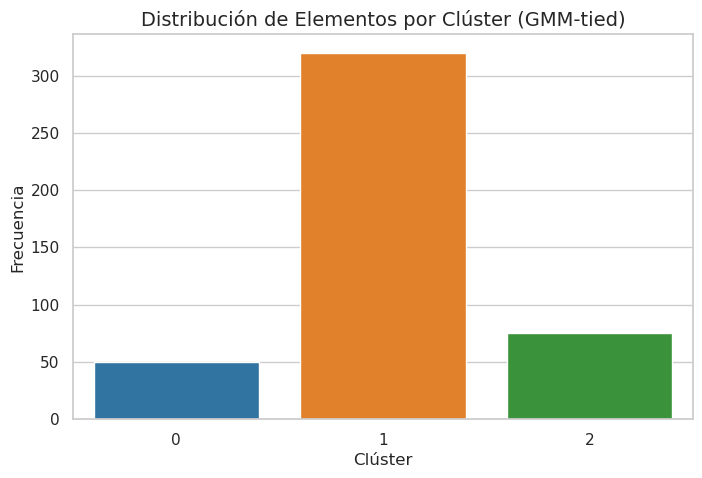


Generando matriz de dispersión (Pairplot)...


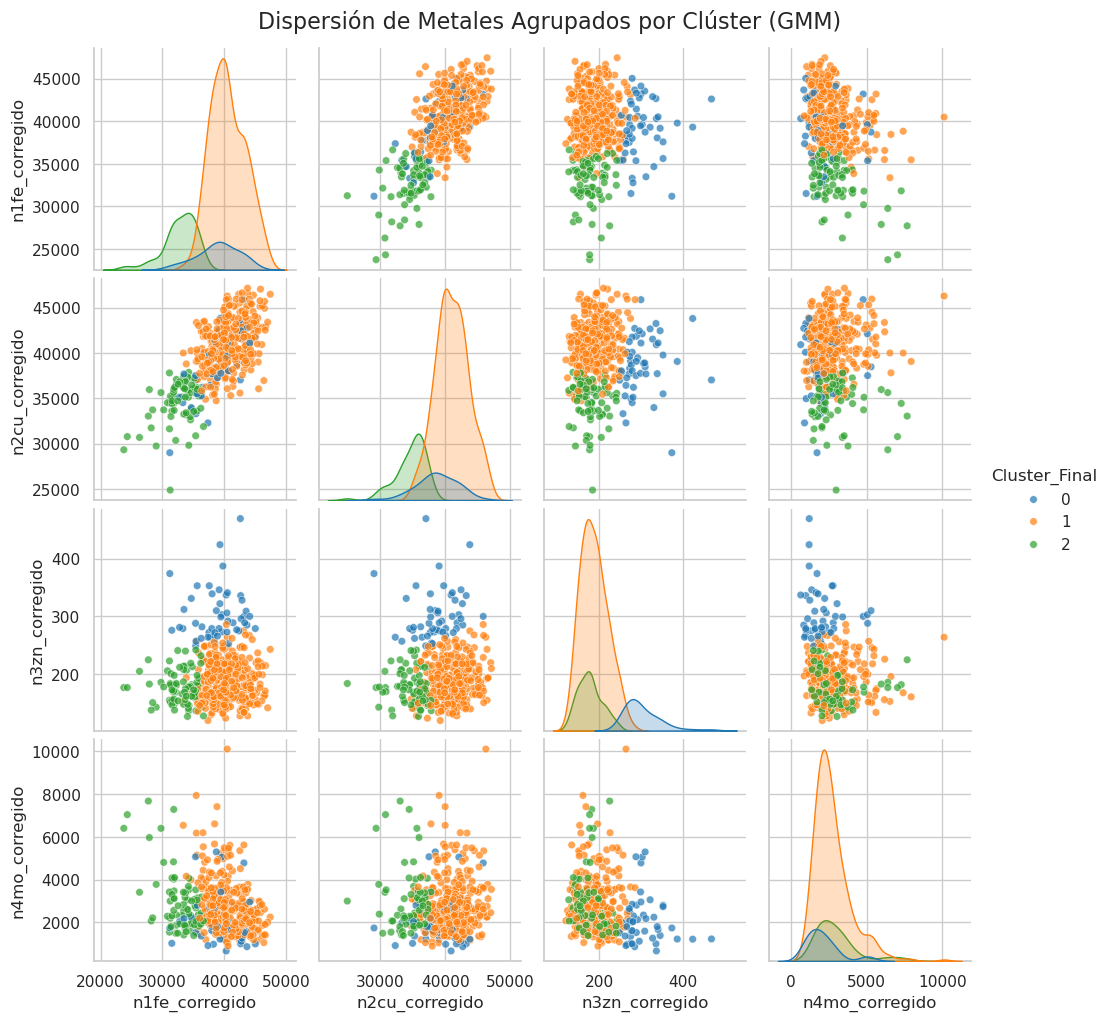

Generando visualización 2D con PCA...


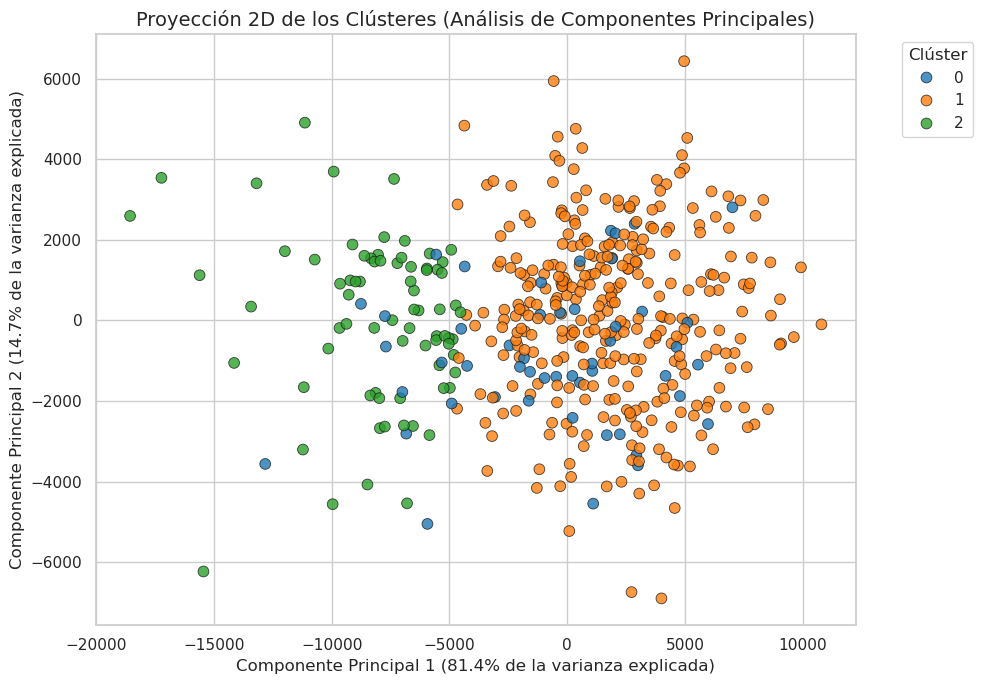

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# 1. Cargar el dataset final con los clústeres asignados
df_final = pd.read_csv('intensidades_sanas_clusterizadas.csv')

# 2. Mostrar cuántos elementos pertenecen a cada grupo (clúster)
print("=== Cantidad de elementos por Clúster ===")
# CORRECCIÓN: La columna correcta generada por el pipeline anterior es 'Cluster_Final'
conteo_clusteres = df_final['Cluster_Final'].value_counts().sort_index()
for cluster, cantidad in conteo_clusteres.items():
    nombre = "Ruido (Outliers)" if cluster == -1 else f"Clúster {cluster}"
    print(f"{nombre}: {cantidad} elementos")

# Configurar el estilo visual
sns.set_theme(style="whitegrid")
paleta_colores = "tab10" # Paleta para distinguir bien los grupos

# 3. Gráfico 1: Gráfico de barras con la cantidad por clúster
plt.figure(figsize=(8, 5))
sns.countplot(data=df_final, x='Cluster_Final', palette=paleta_colores)
# CORRECCIÓN: Actualización del título para reflejar el modelo real (GMM)
plt.title('Distribución de Elementos por Clúster (GMM-tied)', fontsize=14)
plt.xlabel('Clúster')
plt.ylabel('Frecuencia')
plt.show()

# Seleccionar las columnas de los metales para graficar la dispersión
columnas_metales = ['n1fe_corregido', 'n2cu_corregido', 'n3zn_corregido', 'n4mo_corregido']

# 4. Gráfico 2: Pairplot (Matriz de dispersión) para ver relaciones entre metales
print("\nGenerando matriz de dispersión (Pairplot)...")
g = sns.pairplot(df_final, vars=columnas_metales, hue='Cluster_Final', 
                 palette=paleta_colores, plot_kws={'alpha': 0.7, 's': 30})
g.fig.suptitle('Dispersión de Metales Agrupados por Clúster (GMM)', y=1.02, fontsize=16)
plt.show()

# 5. Gráfico 3: Proyección en 2D usando PCA para visualizar cómo se separan los grupos
print("Generando visualización 2D con PCA...")
pca = PCA(n_components=2)
df_final[['PCA1', 'PCA2']] = pca.fit_transform(df_final[columnas_metales])

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_final, x='PCA1', y='PCA2', hue='Cluster_Final', 
                palette=paleta_colores, alpha=0.8, s=60, edgecolor='k')

# Añadir títulos y etiquetas con el porcentaje de varianza explicada
var_exp = pca.explained_variance_ratio_
plt.title('Proyección 2D de los Clústeres (Análisis de Componentes Principales)', fontsize=14)
plt.xlabel(f'Componente Principal 1 ({var_exp[0]:.1%} de la varianza explicada)')
plt.ylabel(f'Componente Principal 2 ({var_exp[1]:.1%} de la varianza explicada)')
plt.legend(title='Clúster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [5]:
import pandas as pd
df=pd.read_csv('/home/daigo/data2Tesis/data/processed/data_cobre_c2v3.csv')
df.max(numeric_only=True)

tara           1.400000e+02
tweight        1.333400e+04
dweight        1.121500e+03
pweight        1.322500e+04
chemical_id    1.750009e+10
%Fe            3.737000e+01
%Cu            3.002000e+01
%Zn            1.884000e+00
%Mo            7.341000e+00
%Ins           3.818000e+04
pSol           1.180600e+02
dtype: float64

In [6]:
print(df[df['chemical_id'] > 1e9])

            date      time   tara  tweight  dweight  pweight   chemical_id  \
751   2024/03/25  12:26:00  110.5    851.0    306.0    740.5  1.711387e+09   
752   2024/03/25  12:28:00  109.0    761.5    157.5    652.5  1.711388e+09   
753   2024/03/25  12:34:00  108.5   1020.0    104.0    911.5  1.711388e+09   
754   2024/03/25  12:37:00  110.0    827.5    291.0    717.5  1.711388e+09   
755   2024/03/25  12:41:00  109.5    919.5    269.5    810.0  1.711388e+09   
...          ...       ...    ...      ...      ...      ...           ...   
2359  2025/12/19  12:34:00  113.5    471.0     20.5    357.5  1.766147e+09   
2360  2025/12/19  12:37:00  115.0    581.5    170.0    466.5  1.766147e+09   
2361  2025/12/19  12:40:00  113.5    589.0    128.0    475.5  1.766147e+09   
2362  2025/12/19  12:43:00  110.0    602.0    112.0    492.0  1.766147e+09   
2363  2025/12/19  12:46:00  100.0    756.0    248.0    656.0  1.766147e+09   

                          MUESTRA     %Fe     %Cu    %Zn    %Mo

In [8]:
print(df[df['chemical_id'] > 2147483647]['chemical_id'])

1941    1.750009e+10
Name: chemical_id, dtype: float64
